In [8]:
# import statements for external packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import math
# import statements from magnipy repo
from magnipy.graphipy import Graphipy
import networkx as nx

In [9]:
G = nx.barbell_graph(8, 4, create_using=None)
G2 = nx.barbell_graph(4, 2, create_using=None)
G3 = nx.barbell_graph(16, 8, create_using=None)

In [10]:
magnis1=[]
magnis2=[]
mag_diffs=[]
ts=np.linspace(0, 10, 100)

for metric in ["shortest_path_distance", "diffusion_distance", "resistance_distance", "heat_kernel_distance"]:
    magni = Graphipy(G=G, mode="structure", metric=metric, ts=ts)
    magni.get_magnitude()
    magnis1.append(magni)
    magni2 = Graphipy(G=G2, mode="structure", metric=metric, ts=ts)
    magni2.get_magnitude()
    magnis2.append(magni2)
    mag_diff = magni._subtract(other=magni2)[0]
    mag_diffs.append(mag_diff)

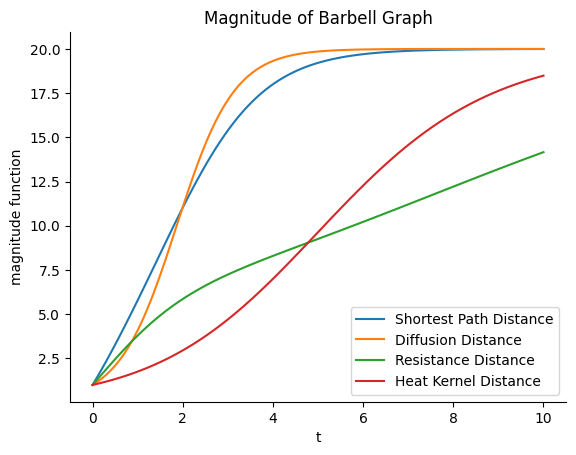

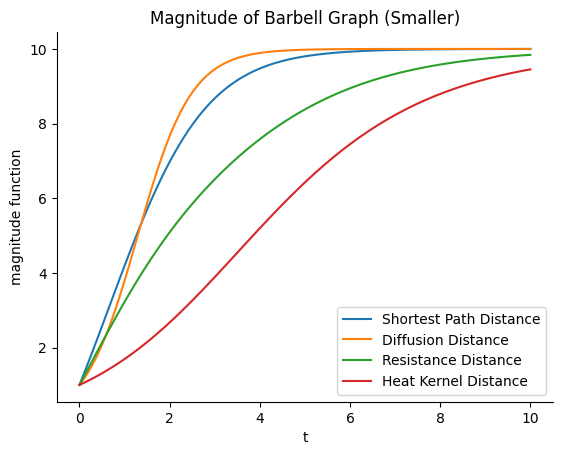

In [11]:
for magni in magnis1:
    magni.plot_magnitude_function()
plt.legend(['Shortest Path Distance', 'Diffusion Distance', 'Resistance Distance', 'Heat Kernel Distance'])
plt.title("Magnitude of Barbell Graph")
plt.show()

for magni in magnis2:
    magni.plot_magnitude_function()
plt.legend(['Shortest Path Distance', 'Diffusion Distance', 'Resistance Distance', 'Heat Kernel Distance'])
plt.title("Magnitude of Barbell Graph (Smaller)")
plt.show()

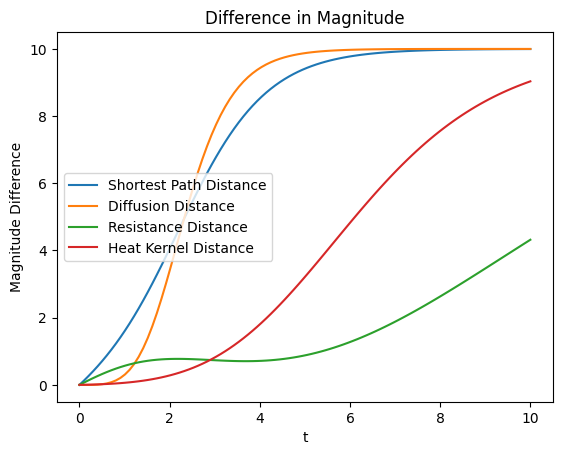

In [12]:
import seaborn as sns
sns.lineplot(x=ts, y=mag_diffs[0], label='Shortest Path Distance')
sns.lineplot(x=ts, y=mag_diffs[1], label='Diffusion Distance')
sns.lineplot(x=ts, y=mag_diffs[2], label='Resistance Distance')
sns.lineplot(x=ts, y=mag_diffs[3], label='Heat Kernel Distance')
plt.title("Difference in Magnitude")
plt.xlabel("t")
plt.ylabel("Magnitude Difference")
plt.legend()